# Project 3 - Results 

**Course:** CIVE 202 - Spring 2026

**Group Number:** 20

**Date:** 3/31/2026

---


# Table of Contents:
 
**Lab 1:** NHTS Dataset Analsis

**Lab 2:** NGSIM Dataset Analysis

**Lab 3:** Intelligent Driver Model (IDM)

---

## Lab 1 - NHTS Dataset
---

## Import Packages:


In [1]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

!pip install matplotlib
!pip install seaborn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')
sns.set_palette('deep')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Use .value_counts() to see how many of each vehicle make are in the data
# This is useful for understanding categorical variables before plotting

nhts_data['make'].value_counts()

In [40]:
# Let's also check for missing values — this is important before plotting!
# Missing values can cause errors or misleading graphs

print(nhts_data.isnull().sum)

<bound method DataFrame.sum of        household_id  census_division  census_region  driver_count  \
0             False            False          False         False   
1             False            False          False         False   
2             False            False          False         False   
3             False            False          False         False   
4             False            False          False         False   
...             ...              ...            ...           ...   
14679         False            False          False         False   
14680         False            False          False         False   
14681         False            False          False         False   
14682         False            False          False         False   
14683         False            False          False         False   

       household_income  household_size  household_workers  home_type  \
0                 False           False              False      Fal

### Horizontal Bar Chart:

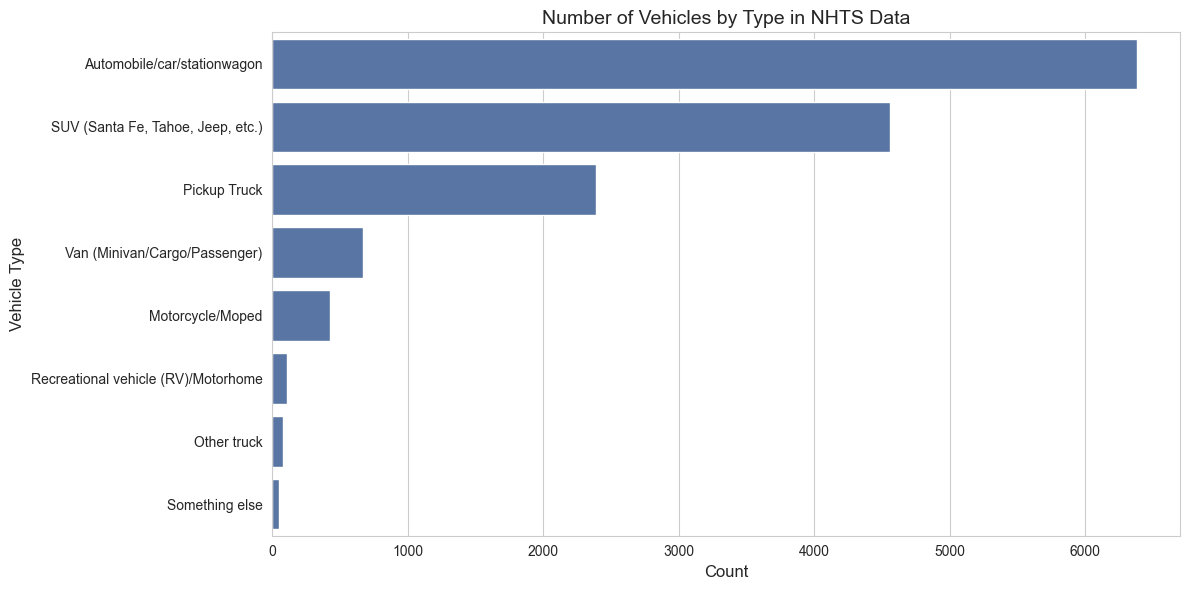

In [4]:
# Create a countplot showing the number of each vehicle type
plt.figure(figsize = (12,6))
# seaborn's countplot automatically counts the categories for you
sns.countplot(data = nhts_data, y = 'vehicle_type', order = nhts_data['vehicle_type'].value_counts().index)
plt.xlabel('Count', fontsize = 12)
plt.ylabel('Vehicle Type', fontsize = 12)
plt.title('Number of Vehicles by Type in NHTS Data', fontsize = 14)

plt.tight_layout()
# plt.savefig("my_countplot.png", dpi = 300, bbox_inche = "tight")
plt.show()
## Step 1: tell Python you are making a figure and what size you want


## Step 2: use sns.countplot to create the plot
# hint: sns.countplot(data=..., x=...) or sns.countplot(data=..., y=...) for horizontal


## Step 3: add labels and title


## Step 4: show the plot


### Boxplot:


<Figure size 1200x600 with 0 Axes>

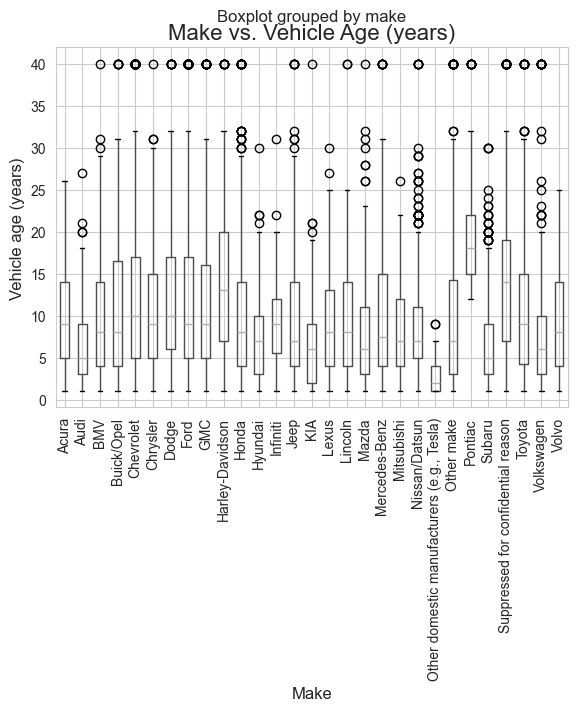

In [6]:
## Let us re-plot the Boxplot and add some customization to it
plt.figure(figsize = (12,6))
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make')
plt.xticks(rotation = 90)
plt.xlabel('Make', fontsize = 12)
plt.ylabel('Vehicle age (years)', fontsize = 12)
plt.title('Make vs. Vehicle Age (years)', fontsize = 16)
plt.show()
## Step 1: tell Python you are making a figure and what size you want the figure to be



## Step 2: call the type of plot and tell the function what variables you want to plot


## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read


### the next two lines create your axis labels

### this line gives your plot a title


## Step 4: tell python to show the plot


### Violin Plot: 


Text(0.5, 1.0, 'Vehicle Age Distribution: Urbam vs Rural Households')

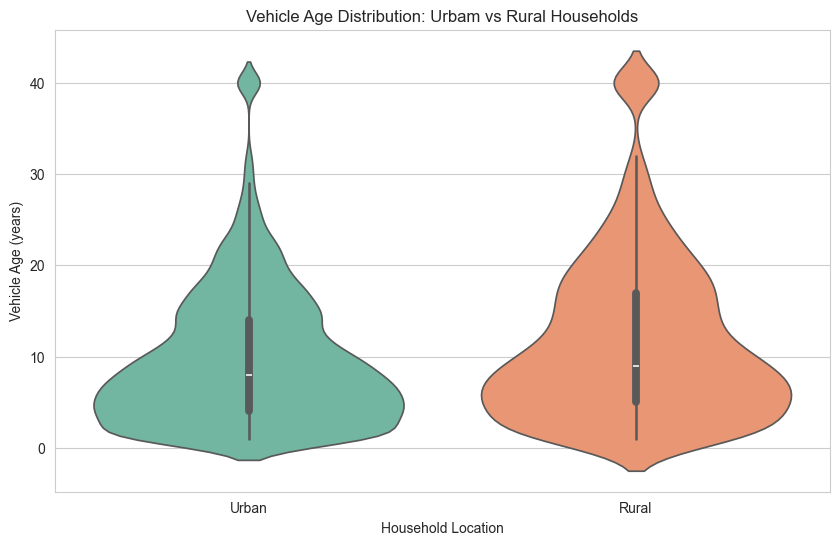

In [55]:
# Create a violin plot comparing vehicle age by household location (Urban vs Rural)
# seaborn's violinplot works very similarly to boxplot

## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize = (10,6))

## Step 2: use sns.violinplot with x='household_location' and y='vehicle_age'
# hint: you can add the argument inner='box' to show a mini boxplot inside the violin!
# use hue='household_location' and legend=False for coloring

sns.violinplot(data = nhts_data, x = 'household_location', y = 'vehicle_age', 
               hue = 'household_location', inner = 'box', palette = 'Set2', legend = False)
## Step 3: add labels and title
plt.xlabel('Household Location')
plt.ylabel('Vehicle Age (years)')
plt.title('Vehicle Age Distribution: Urbam vs Rural Households')

## Step 4: show the plot


### Histogram:


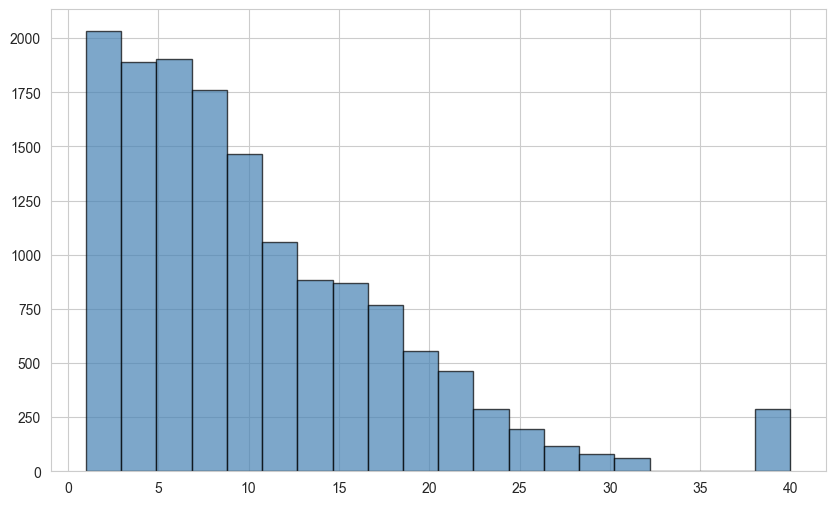

In [58]:
##Let's use matplotlib to create a histogram
plt.figure(figsize = (10,6))

plt.hist(nhts_data['vehicle_age'], bins = 20, edgecolor = 'black', alpha = 0.7, color = 'steelblue')
plt.show()
##Tell Python you are plotting a figure and how big you want the figure to be


## Tell Python what type of plot you want. Here, .hist() creates a histogram


# Then let's label. You'll notice you can change the fontsize of all your labels!


### Histogram:


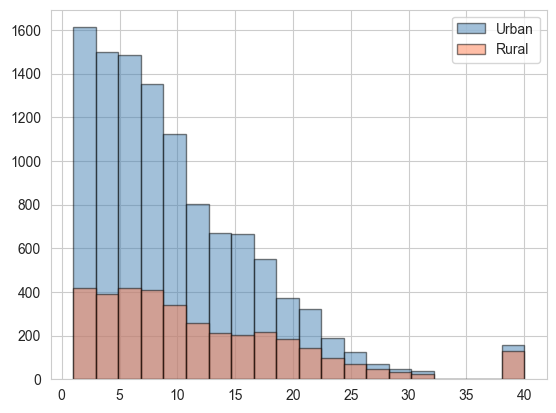

In [67]:
# Create overlapping histograms for Urban vs Rural vehicle ages
# We need to filter the data first, then plot each group separately

#Histogram Number 1
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
#print(urban_ages)

plt.hist(urban_ages, bins = 20, edgecolor = 'black', alpha = 0.5, color = 'steelblue', label = 'Urban')


#Histogram Number 2

rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
#print(urban_ages)

plt.hist(rural_ages, bins = 20, edgecolor = 'black', alpha = 0.5, color = 'coral', label = 'Rural')
plt.legend()
plt.show()

## Step 1: tell Python you are making a figure


## Step 2: filter and plot Urban vehicle ages
# hint: use nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
# use the alpha argument to make bars semi-transparent (e.g., alpha=0.5)


## Step 3: filter and plot Rural vehicle ages on the same figure


## Step 4: add labels, title, and legend



### Bar Chart:


fuel_type
Gas                                  13485
Hybrid, gas/electric, non plug-in      477
Diesel                                 384
Electric only                          186
Plug-in hybrid                          80
Uses other fuel                         34
Biodiesel                                6
Name: count, dtype: int64


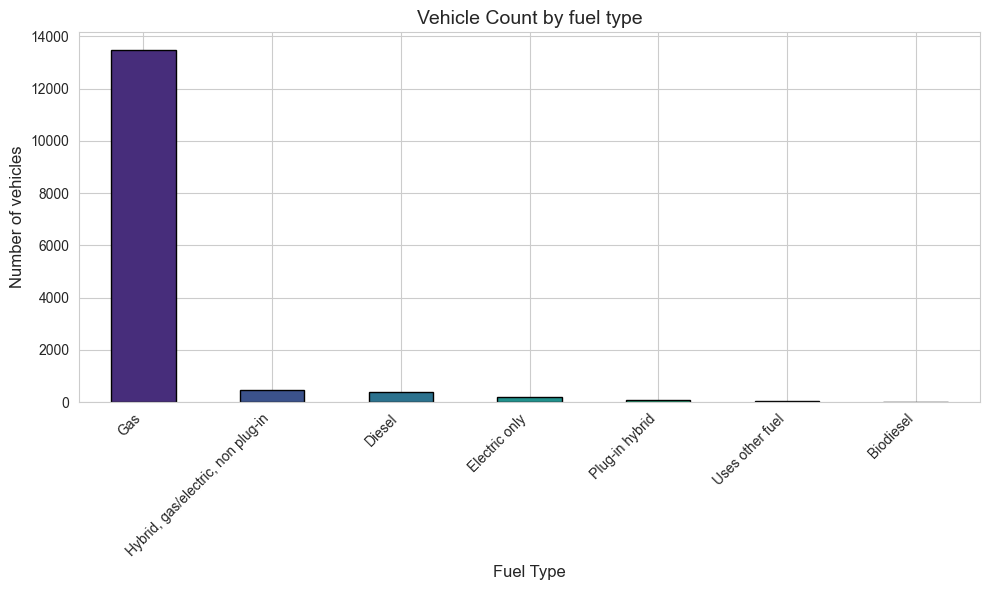

In [74]:
# Simple bar chart: count of vehicles by fuel type
# First we need to count the values, then plot
fuel_counts = nhts_data['fuel_type'].value_counts().dropna()
print(fuel_counts)
plt.figure(figsize = (10,6))
fuel_counts.plot(kind = 'bar', color = sns.color_palette('viridis', len(fuel_counts)), edgecolor = 'black')

## Step 1: count the number of vehicles by fuel type
# hint: use .value_counts()


## Step 2: create the bar plot


## Step 3: add labels and customization
plt.xlabel('Fuel Type', fontsize = 12)
plt.ylabel('Number of vehicles', fontsize = 12)
plt.title('Vehicle Count by fuel type', fontsize = 14)
plt.xticks(rotation = 45, ha = 'right')

## Step 4: show the plot
plt.tight_layout()
plt.show()


### Stacked Bar Chart


<Figure size 2000x1000 with 0 Axes>

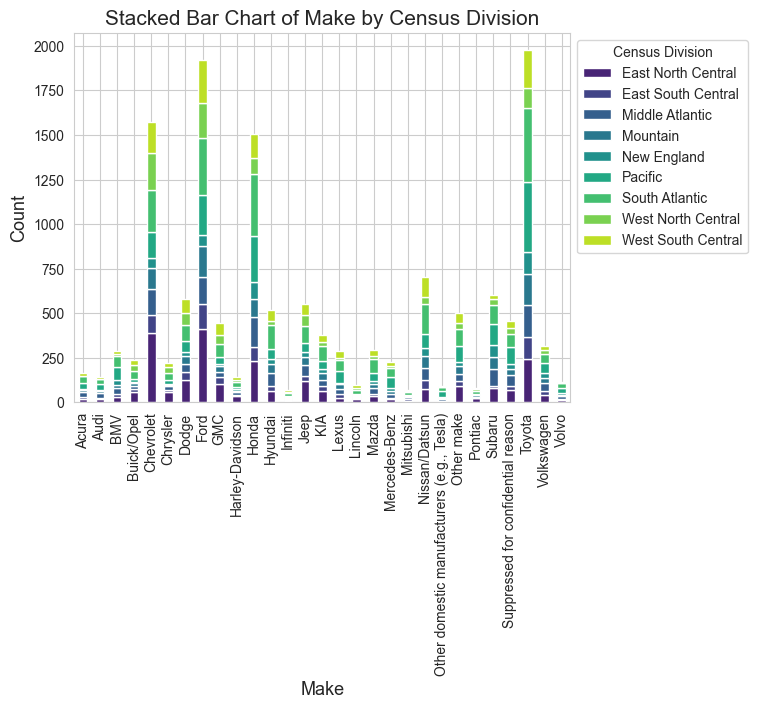

In [104]:
## let's customize our bar chart because our data right now isn't grouped correctly.

# Filter out NA values (assuming NA represents missing values)
nhts_data = nhts_data.dropna(subset = ['make'])

# Grouping and counting by 'make' and 'census_division'
data_grouped = nhts_data.groupby(['make', 'census_division']).size().unstack(fill_value=0) 
#print(data_grouped)
# Plotting
plt.figure(figsize = (20,10))
data_grouped.plot(kind = 'bar', stacked = True, color=sns.color_palette('viridis', len(data_grouped.columns)))
# Plotting stacked bar chart
plt.xlabel('Make', fontsize =13)
plt.ylabel('Count', fontsize = 13)
plt.title('Stacked Bar Chart of Make by Census Division', fontsize = 15)
plt.xticks(rotation=90)

# Customizing the plot
plt.legend(title = 'Census Division', bbox_to_anchor =(1,1), loc = 'upper left')

#Show the plot
plt.show()


### Pie Chart:


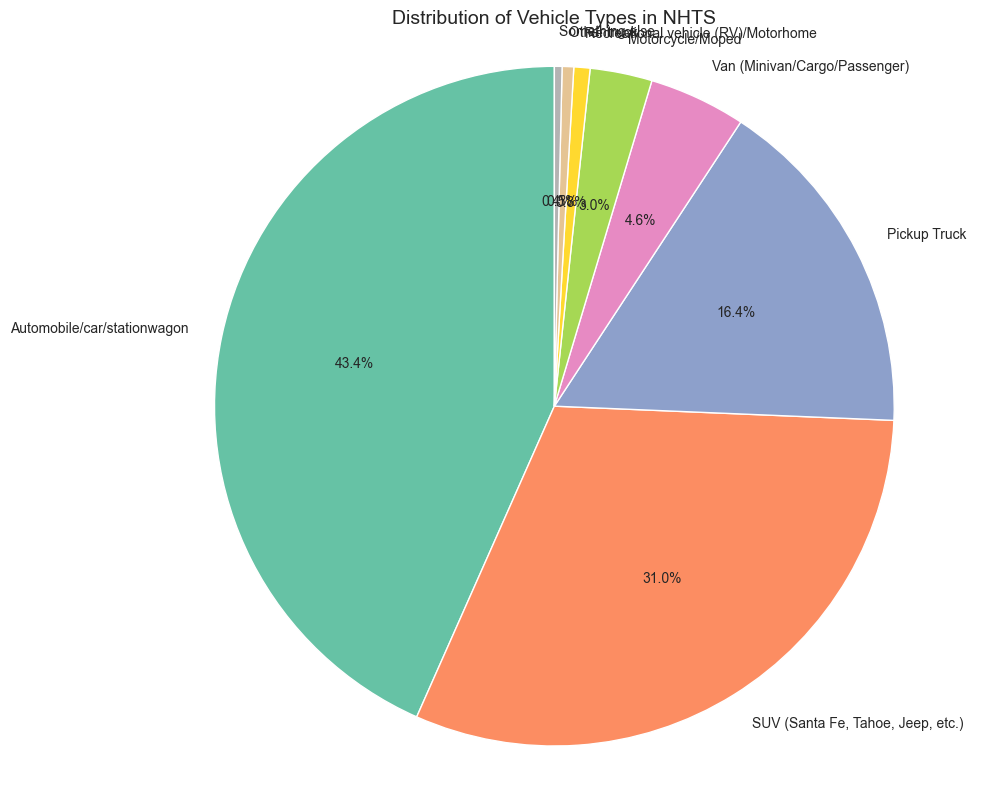

In [92]:
# Create a pie chart showing the proportion of each vehicle type
type_counts = nhts_data['vehicle_type'].value_counts()
plt.figure(figsize = (10,8))
plt.pie(type_counts, labels = type_counts.index, autopct = '%1.1f%%', startangle=90, 
        colors=sns.color_palette('Set2', len(type_counts)), textprops={'fontsize':10})

plt.axis('equal')
plt.title('Distribution of Vehicle Types in NHTS', fontsize = 14)
plt.tight_layout()
plt.show()
## Step 1: count the vehicles by type
# hint: use .value_counts()


## Step 2: create the pie chart
# hint: use plt.pie() with arguments: labels=..., autopct='%1.1f%%', startangle=90
# autopct adds percentage labels to each slice


## Step 3: add title and make it look nice
# hint: plt.axis('equal') ensures the pie is a circle, not an ellipse



### Correlation Heatmap:

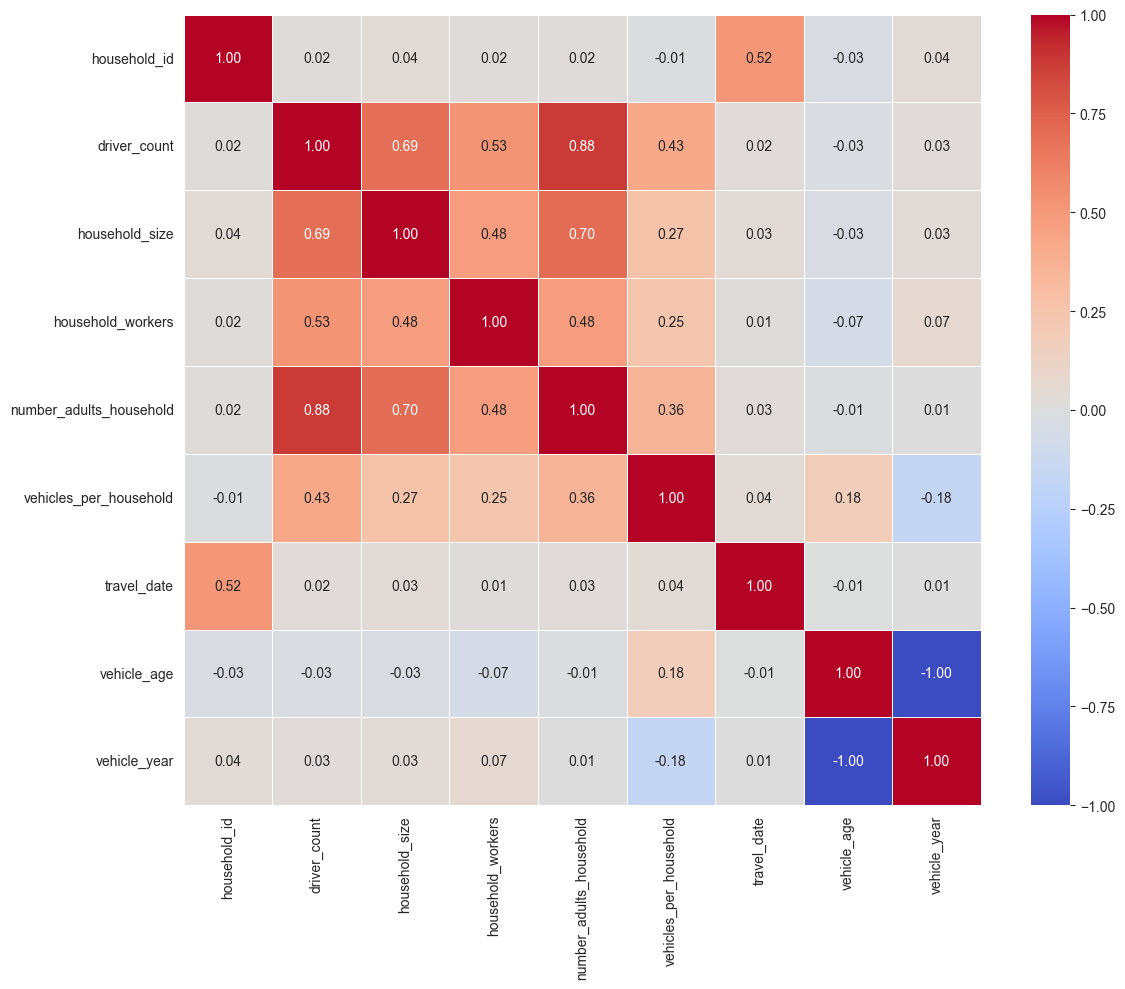

In [96]:
# Create a correlation heatmap for the numeric variables in the NHTS data

## Step 1: select only the numeric columns from the dataframe
# hint: use nhts_data.select_dtypes(include=[np.number])
numeric_data = nhts_data.select_dtypes(include = [np.number])

## Step 2: calculate the correlation matrix
# hint: use .corr()
corr_matrix = numeric_data.corr()

## Step 3: create the heatmap
# hint: use sns.heatmap() with arguments: annot=True (show numbers), cmap='coolwarm', fmt='.2f'
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidth = 0.5, vmin = -1, vmax = 1)
plt.tight_layout()
plt.show()
## Step 4: add title and show


## Lab 2 - NGSIM Dataset
---

### Line Graph:


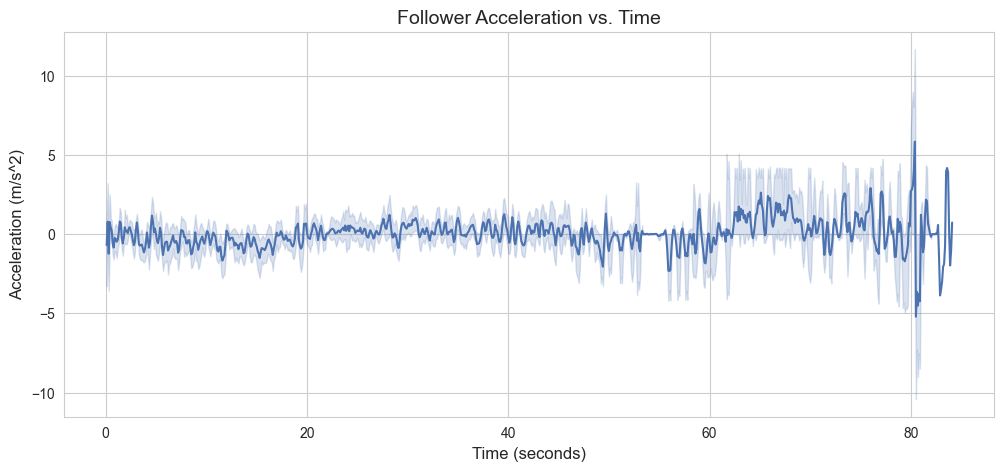

In [9]:
### Plotting Acceleration vs Time

# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize = (12,5))

# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_acc(m/s^2)'])
# Step 3: add customizations
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Acceleration (m/s^2)', fontsize = 12)
plt.title('Follower Acceleration vs. Time', fontsize = 14)
plt.show()


### Line Graph:


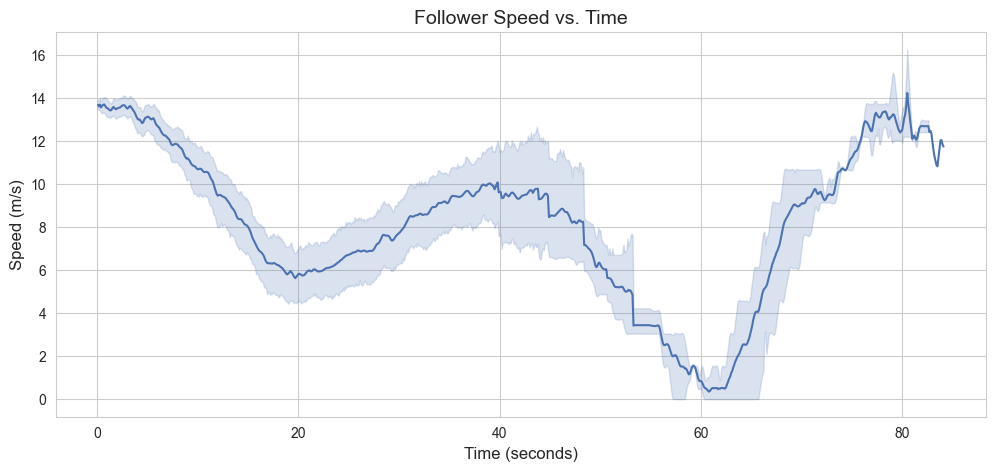

In [10]:
### Plotting Speed vs Time


# replicate the above steps, but now visualize the follower_speed(m/s) data with time 

plt.figure(figsize = (12,5))

sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_speed(m/s)'])

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Speed (m/s)', fontsize = 12)
plt.title('Follower Speed vs. Time', fontsize = 14)
plt.show()


### Line Graph:


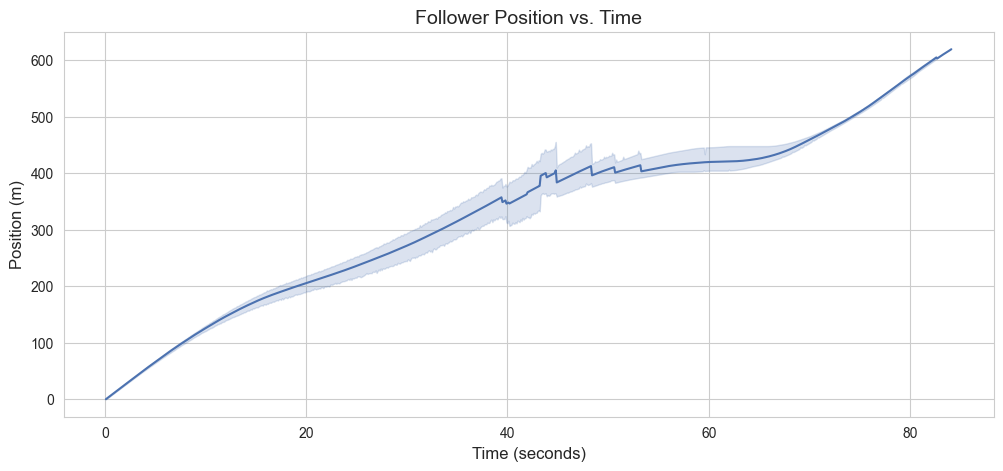

In [11]:
### Plotting Position vs Time

# replicate the above steps, but now visualize the follower_position(m) data with time 

plt.figure(figsize = (12,5))

sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_position(m)'])

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m)', fontsize = 12)
plt.title('Follower Position vs. Time', fontsize = 14)
plt.show()

### Line Graph:


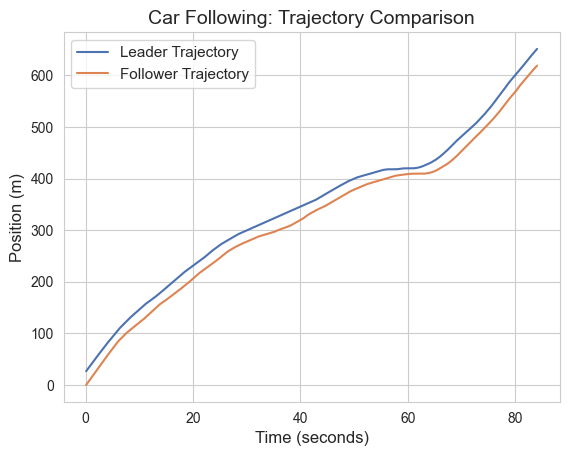

In [12]:
# Select a trajectory number
trajectory_number = 1 # vehicle pair x

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Plot the position of both vehicles over time

# follow similar steps of what we learned
# but here you need to plot two lines together:
    # one lineplot for leader position vs time 
    # another lineplot for follower position vs time

sns.lineplot(x = data_subset['Time'], y = data_subset['leader_position(m)'], label = 'Leader Trajectory')
sns.lineplot(x = data_subset['Time'], y = data_subset['follower_position(m)'], label = 'Follower Trajectory')
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m)', fontsize = 12)
plt.title('Car Following: Trajectory Comparison', fontsize = 14)
plt.legend(fontsize = 11)
plt.show()

### Line Graph:


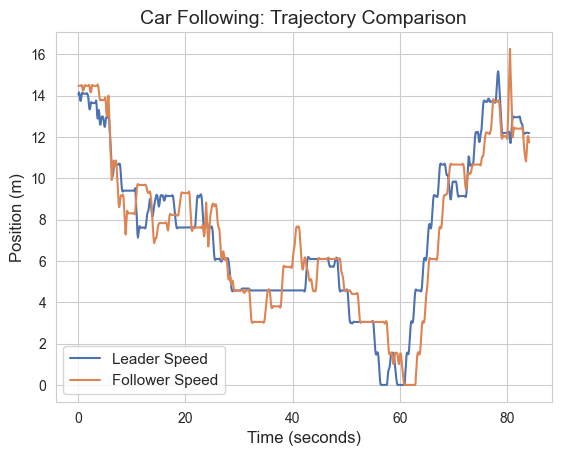

In [13]:
# Now replicate the same but visualizing speed

sns.lineplot(x = data_subset['Time'], y = data_subset['leader_speed(m/s)'], label = 'Leader Speed')
sns.lineplot(x = data_subset['Time'], y = data_subset['follower_speed(m/s)'], label = 'Follower Speed')
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m)', fontsize = 12)
plt.title('Car Following: Trajectory Comparison', fontsize = 14)
plt.legend(fontsize = 11)
plt.show()

### Line Graph:


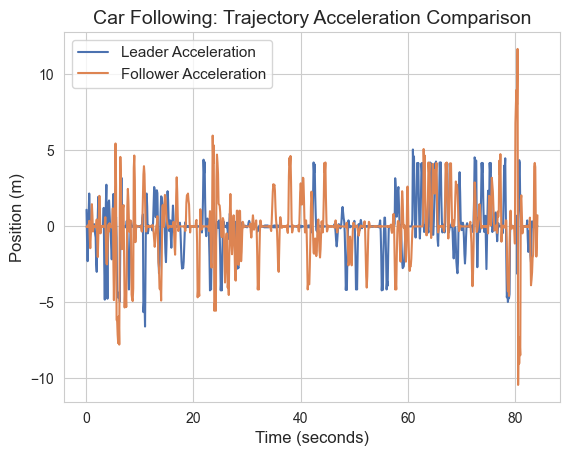

In [14]:
# Now replicating the same but visualizing acceleration

sns.lineplot(x = data_subset['Time'], y = data_subset['leader_acc(m/s^2)'], label = 'Leader Acceleration')
sns.lineplot(x = data_subset['Time'], y = data_subset['follower_acc(m/s^2)'], label = 'Follower Acceleration')
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m)', fontsize = 12)
plt.title('Car Following: Trajectory Acceleration Comparison', fontsize = 14)
plt.legend(fontsize = 11)
plt.show()


### Line Graph:


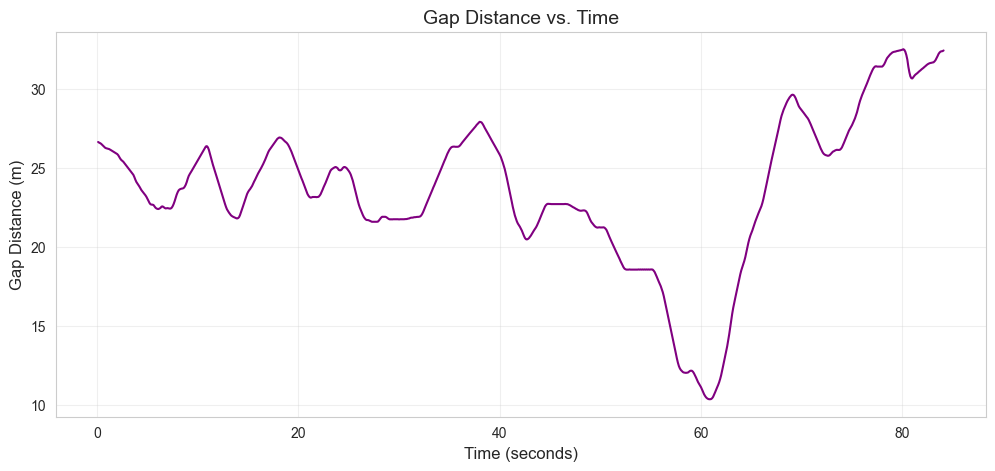

In [15]:
# Now try to plot the gap distance between two vehicle pairs. Gap = position of leader - position of follower
# Plot the gap distance over time 
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

plt.figure(figsize = (12,5))
plt.plot(data_subset['Time'], gap_distance, color = 'purple', linewidth = 1.5)
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Gap Distance (m)', fontsize = 12)
plt.title('Gap Distance vs. Time', fontsize = 14)
plt.grid(True, alpha = 0.3)
plt.show()


### Line Graph:


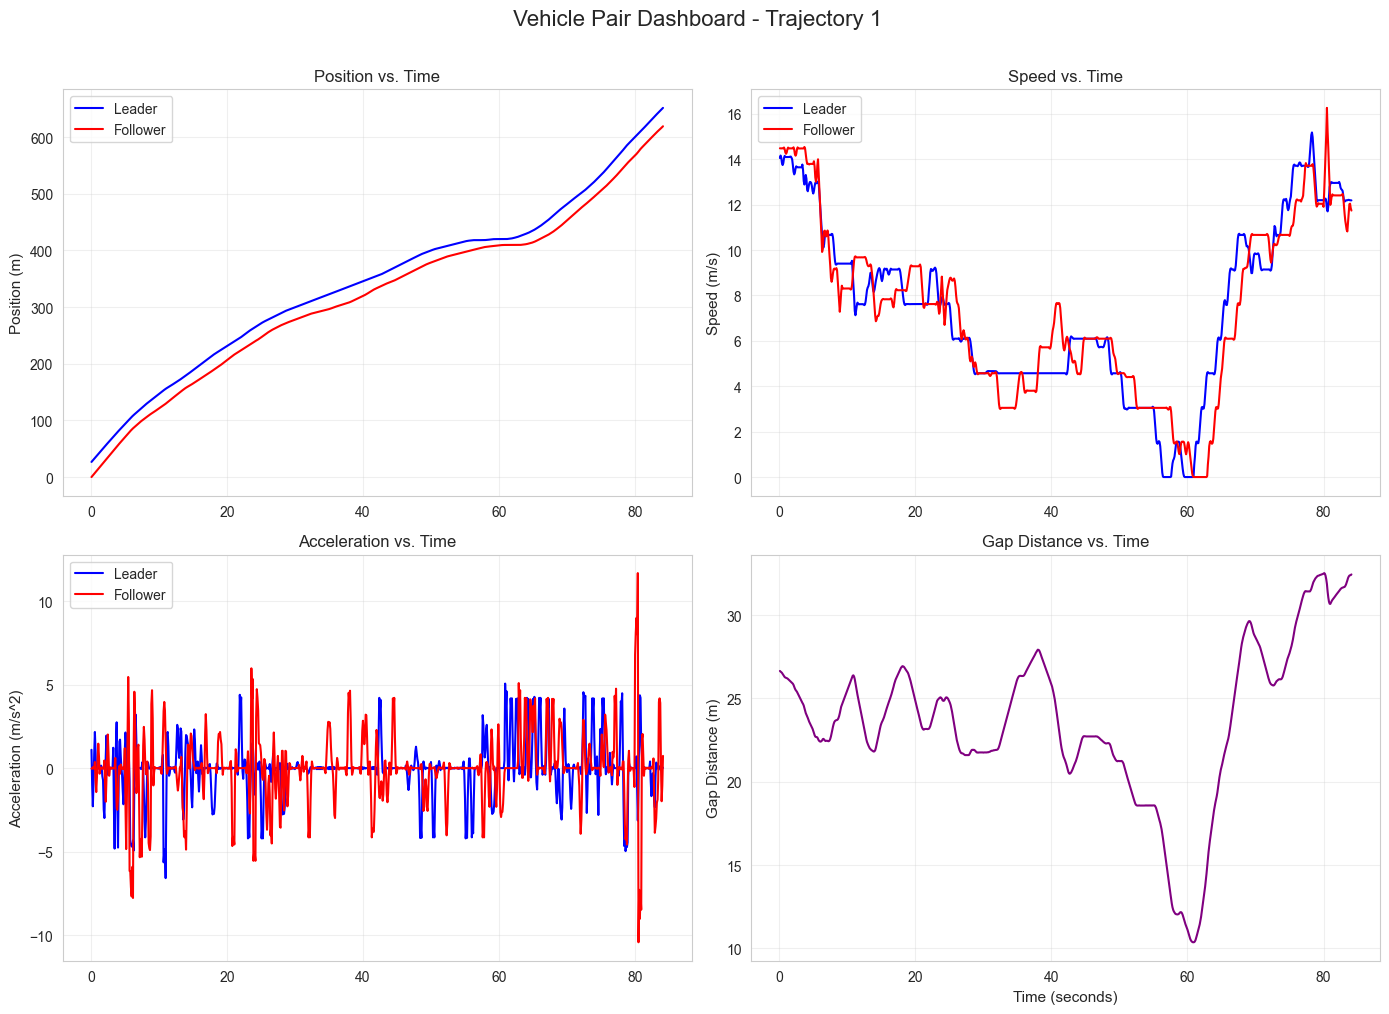

In [16]:
# Create a 2x2 subplot figure showing: trajectory, speed, acceleration, and gap for one vehicle pair

# Step 1: Select a trajectory number and create the subset
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

# Step 2: Create the figure with 2 rows and 2 columns
# hint: fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig, axes = plt.subplots(2,2, figsize = (14,10))

# Step 3: Top-left (axes[0,0]): Position vs Time for both leader and follower
axes[0,0].plot(time, data_subset['leader_position(m)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[0,0].plot(time, data_subset['follower_position(m)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[0,0].set_ylabel('Position (m)', fontsize = 11)
axes[0,0].set_title('Position vs. Time', fontsize = 12)
axes[0,0].legend(fontsize = 10)
axes[0,0].grid(True, alpha = 0.3)

# Step 4: Top-right (axes[0,1]): Speed vs Time for both leader and follower
axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[0,1].set_ylabel('Speed (m/s)', fontsize = 11)
axes[0,1].set_title('Speed vs. Time', fontsize = 12)
axes[0,1].legend(fontsize = 10)
axes[0,1].grid(True, alpha = 0.3)

# Step 5: Bottom-left (axes[1,0]): Acceleration vs Time for both leader and follower
axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[1,0].set_ylabel('Acceleration (m/s^2)', fontsize = 11)
axes[1,0].set_title('Acceleration vs. Time', fontsize = 12)
axes[1,0].legend(fontsize = 10)
axes[1,0].grid(True, alpha = 0.3)

# Step 6: Bottom-right (axes[1,1]): Gap Distance vs Time
axes[1,1].plot(time, gap, 'purple', linewidth = 1.5)
axes[1,1].set_xlabel('Time (seconds)', fontsize =11)
axes[1,1].set_ylabel('Gap Distance (m)', fontsize = 11)
axes[1,1].set_title('Gap Distance vs. Time', fontsize = 12)
axes[1,1].grid(True, alpha = 0.3)


# Step 7: Add title for the whole figure and adjust layout

plt.suptitle(f' Vehicle Pair Dashboard - Trajectory {trajectory_number}', fontsize = 16, y=1.01)
plt.tight_layout()
plt.show()

### Line Graph:


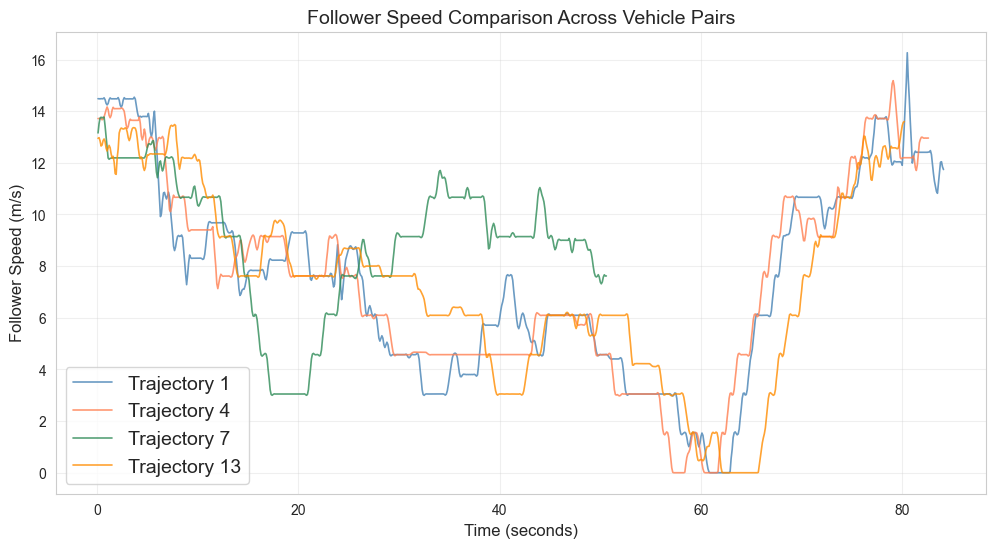

In [17]:
# Compare the follower speed profile for 4 different trajectory pairs on the same plot
# This shows us the variation in driving behavior across different vehicle pairs

# hint: loop through trajectory_numbers = [1, 4, 7, 13]
# for each one, filter the data and plot the follower speed vs time

trajectory_numbers = [1, 4, 7, 13]
colors = ['steelblue', 'coral', 'seagreen', 'darkorange']

plt.figure(figsize = (12,6))

for traj, color, in zip(trajectory_numbers, colors):
    subset = ngsim_data[ngsim_data['trajectory_number'] == traj]
    plt.plot(subset['Time'].values, subset['follower_speed(m/s)'].values, color = color, linewidth = 1.2, label = f'Trajectory {traj}', alpha = 0.8)

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Follower Speed (m/s)', fontsize = 12)
plt.title('Follower Speed Comparison Across Vehicle Pairs', fontsize = 14)
plt.legend(fontsize = 14)
plt.grid(True, alpha = 0.3)

plt.show()



### Histogram:


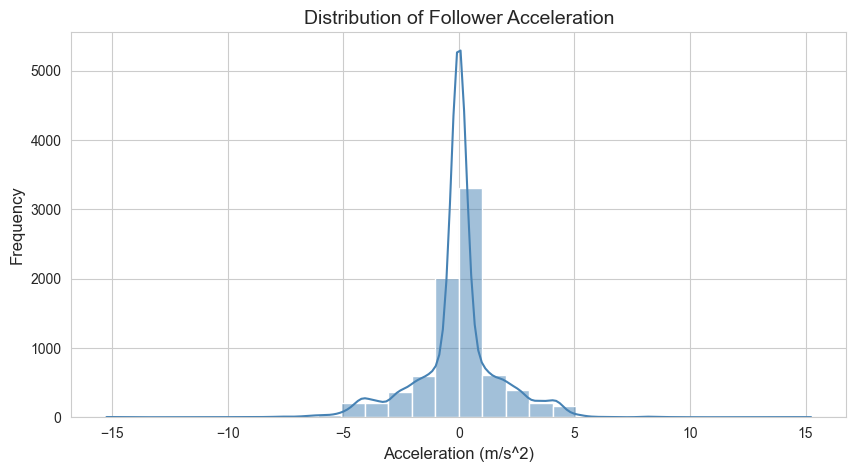

In [18]:
## Here you are asked to show a histogram of the acceleration. Specifically, we want to see how acceleration values are distributed for the following cars
# here try to use the sns.histplot graph 
plt.figure(figsize = (10,5))
sns.histplot(ngsim_data['follower_acc(m/s^2)'], bins = 30, kde = True, color = 'steelblue')
plt.xlabel('Acceleration (m/s^2)', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.title('Distribution of Follower Acceleration', fontsize = 14)
plt.show()

### Histogram:


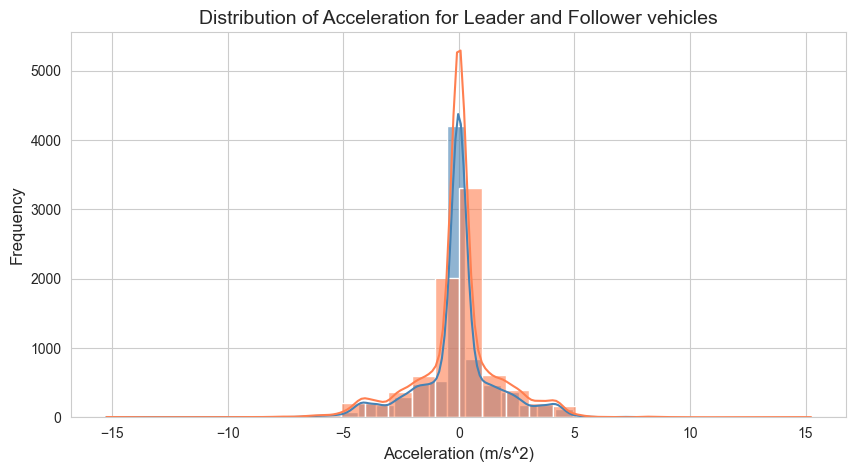

In [19]:
# What if we want to visualize how the distribution of acceleration changes between leader and follower
# Plot the two histplot of leader and follower on same plot 

# This histogram compares the distribution of acceleration for leader and follower vehicles on the same plot.
plt.figure(figsize = (10,5))
sns.histplot(ngsim_data['leader_acc(m/s^2)'], bins = 30, kde = True, label = 'Leader Acceleration', color = 'steelblue', alpha = 0.6)
sns.histplot(ngsim_data['follower_acc(m/s^2)'], bins = 30, kde = True, label = 'Follower Acceleration', color = 'coral', alpha = 0.6)

# Customize the plot
plt.xlabel('Acceleration (m/s^2)', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.title('Distribution of Acceleration for Leader and Follower vehicles', fontsize = 14)
plt.show()

### Scatter Plot:


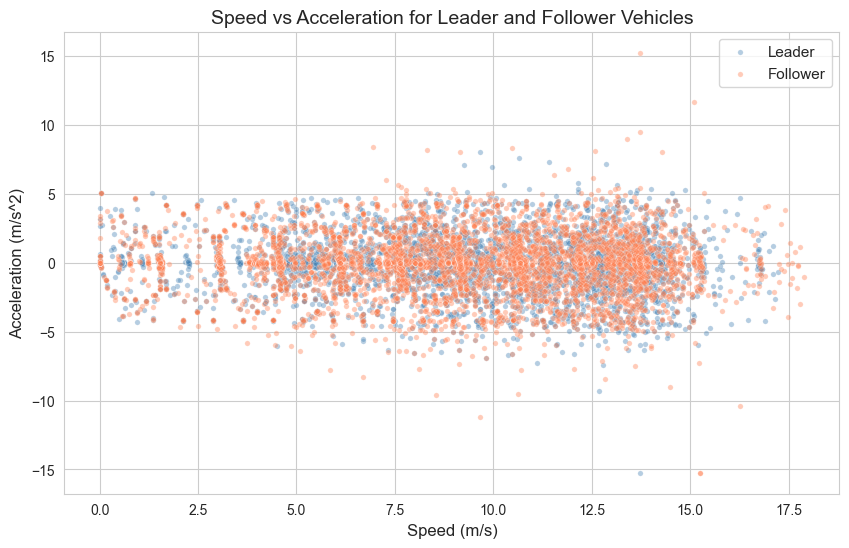

In [20]:
# We want to understand how acceleration changes with speed for both leader and follower vehicles. 

# create graph that uses sns.scatterplot to visualize:
    # speed on x axis
    # acceleration on y axis 
    # showing both leader and follower data 



# This scatter plot visualizes how acceleration changes with speed for both leader and follower vehicles.
plt.figure(figsize = (10,6))
sns.scatterplot(x = ngsim_data['leader_speed(m/s)'], y = ngsim_data['leader_acc(m/s^2)'], label = 'Leader', alpha = 0.4, color = 'steelblue', s = 15)
sns.scatterplot(x = ngsim_data['follower_speed(m/s)'], y = ngsim_data['follower_acc(m/s^2)'], label = 'Follower', alpha = 0.4, color = 'coral', s = 15)

plt.xlabel('Speed (m/s)', fontsize = 12)
plt.ylabel('Acceleration (m/s^2)', fontsize = 12)
plt.title('Speed vs Acceleration for Leader and Follower Vehicles', fontsize = 14)
plt.legend(fontsize = 11)
plt.show()

### Scatter Plot:


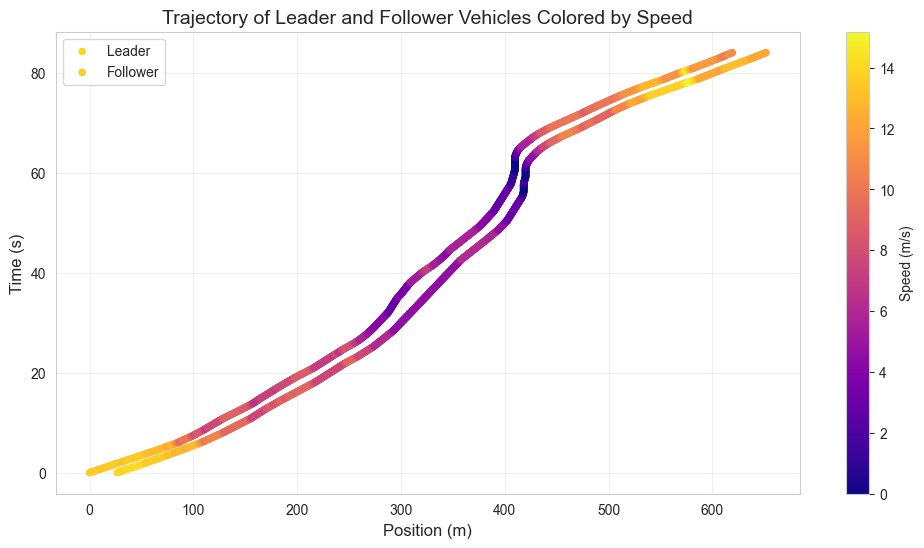

In [22]:
# Step 1: Select a trajectory number
trajectory_number = 1  # Example trajectory

# Step 2: Select the data based on the subset
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Step 3: Tell python you want to plot a figure and assign a size
plt.figure(figsize=(12,6))

# Step 4: Create a scatter plot for leader vehicle of position vs time
leader_plot = plt.scatter(data_subset['leader_position(m)'], data_subset['Time'], 
                          c=data_subset['leader_speed(m/s)'],cmap='plasma',s=20,label='Leader')

# Step 5: Do the same for the following vehicle data
plt.scatter(data_subset['follower_position(m)'],data_subset['Time'],
            c=data_subset['follower_speed(m/s)'],cmap='plasma',s=20,label='Follower')

# Add colorbar to indicate speed values
cbar = plt.colorbar(leader_plot)
cbar.set_label('Speed (m/s)')

# Labels and title
plt.xlabel('Position (m)', fontsize=12)
plt.ylabel('Time (s)', fontsize=12)
plt.title('Trajectory of Leader and Follower Vehicles Colored by Speed', fontsize=14)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Lab 3 - Intelligent Driver Model (IDM)
---

### Import Packages


In [17]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Visualize the Simulation Results - Trajectory Plot


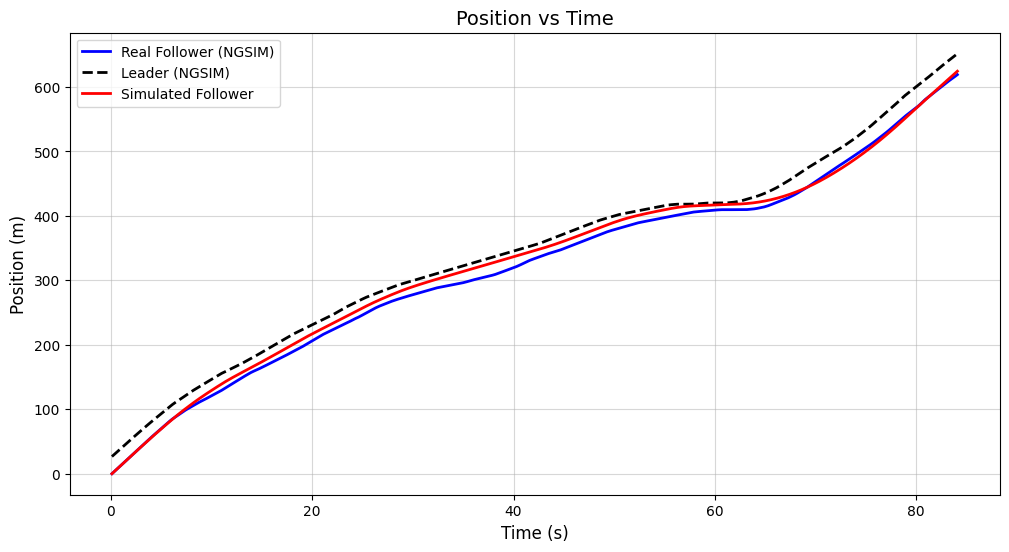

In [75]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize = (12,6))
plt.plot(time_data, data_subset['follower_position(m)'].values,'b-', linewidth = 2, label = 'Real Follower (NGSIM)')
plt.plot(time_data, leader_position, 'k--', linewidth = 2, label = 'Leader (NGSIM)')
plt.plot(time_data, sim_position, 'r-', linewidth = 2,  label = 'Simulated Follower')
plt.xlabel('Time (s)', fontsize = 12)
plt.ylabel('Position (m)', fontsize = 12)
plt.legend()
plt.title('Position vs Time', fontsize = 14)
plt.grid(True, alpha = 0.5)
plt.show()


